# Simulation with OpenMM

In this notebook, we will perform a simple MD simulation of hen egg white lysozyme via OpenMM. We will set up the system, define the force field, and run the simulation to analyze the results. The steps include:
1. **System Setup**: Load the protein structure and prepare the system for simulation.
2. **Force Field Definition**: Apply the appropriate force field parameters to the system.
3. **Simulation Execution**: Run the molecular dynamics simulation and collect data.

In [8]:
from openmm import *
from openmm.app import *
from openmm.unit import *
import numpy as np
import matplotlib.pyplot as plt

# Input Files

pdbx = PDBxFile('data/1AKI-processed.cif')
forcefield = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')

# System Configuration

nonbondedMethod = PME
nonbondedCutoff = 1.0*nanometers
constraints = HBonds
rigidWater = True
constraintTolerance = 0.000001
hydrogenMass = 1.5*amu
ewaldErrorTolerance = 0.0005
# Integration Options

dt = 0.002*picoseconds
temperature = 300*kelvin
friction = 1.0/picosecond
pressure = 1.0*atmospheres
barostatInterval = 25

In [9]:
# Simulation Options

steps = 20000
equilibrationSteps = 1000
dcdReporter = DCDReporter('trajectory.dcd', 1000)
dataReporter = StateDataReporter('log.txt', 100, totalSteps=steps,
    step=True, speed=True, progress=True, potentialEnergy=True, temperature=True, density=True, separator='\t')
checkpointReporter = CheckpointReporter('checkpoint.chk', 1000)

# Prepare the Simulation

print('Building system...')
topology = pdbx.topology
positions = pdbx.positions
system = forcefield.createSystem(topology, nonbondedMethod=nonbondedMethod, nonbondedCutoff=nonbondedCutoff,
    constraints=constraints, rigidWater=rigidWater, ewaldErrorTolerance=ewaldErrorTolerance, hydrogenMass=hydrogenMass)
system.addForce(MonteCarloBarostat(pressure, temperature, barostatInterval))
integrator = LangevinMiddleIntegrator(temperature, friction, dt)
integrator.setConstraintTolerance(constraintTolerance)
simulation = Simulation(topology, system, integrator)
simulation.context.setPositions(positions)

# Minimize and Equilibrate

print('Performing energy minimization...')
simulation.minimizeEnergy()
print('Equilibrating...')
simulation.context.setVelocitiesToTemperature(temperature)
simulation.step(equilibrationSteps)

# Simulate

print('Simulating...')
simulation.reporters.append(dcdReporter)
simulation.reporters.append(dataReporter)
simulation.reporters.append(checkpointReporter)
simulation.currentStep = 0
simulation.step(steps)

Building system...
Performing energy minimization...
Equilibrating...
Simulating...


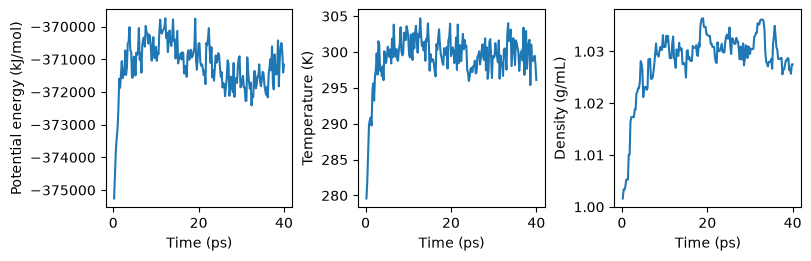

In [10]:
step, pe, temp, rho = np.loadtxt("log.txt", delimiter="\t", usecols=(1, 2, 3, 4)).T
time = step * dt.value_in_unit(picosecond)

figure = plt.figure(figsize=(8, 2.5), layout="constrained")

axes_pe = figure.add_subplot(1, 3, 1)
axes_pe.plot(time, pe)
axes_pe.set_xlabel("Time (ps)")
axes_pe.set_ylabel("Potential energy (kJ/mol)")

axes_temp = figure.add_subplot(1, 3, 2)
axes_temp.plot(time, temp)
axes_temp.set_xlabel("Time (ps)")
axes_temp.set_ylabel("Temperature (K)")

axes_rho = figure.add_subplot(1, 3, 3)
axes_rho.plot(time, rho)
axes_rho.set_xlabel("Time (ps)")
axes_rho.set_ylabel("Density (g/mL)")

plt.show()